## Homework 10

In this homework, you are going to use the code from ```TrafficSignsClassification``` notebook and create your own traffic sign classifier.

### Step 1
Use the data from ```data/subset_homework``` folder and visualize some examples. How many images are there for each class?

### Step 2
Run the training with one single neuron (as we did in the lecture). What accuracy can you achieve?

### Step 3
Make further modifications to improve the accuracy (e.g. add more neurons, more layers, etc.). What is the maximum accuracy you can achieve?


In [1]:
import cv2
import tensorflow as tf
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import joblib

from matplotlib import pyplot as plt

In [2]:
plt.rcParams['figure.figsize'] = [15, 6]
sns.set_style('whitegrid')

In [3]:
def calculate_optimal_factor(img: np.ndarray) -> np.ndarray:
    """
        Calculate the optimal factor to adjust the brightness of the image.
        We assume that the optimal mean brightness is around 127.5 (half of 255).
        If the mean brightness of the image is less than 127.5, we need to increase the brightness.
        If the mean brightness of the image is greater than 127.5, we need to decrease the brightness.
        Args:       img (np.ndarray): Input image as a numpy array.
        Returns:    np.ndarray: Image with adjusted brightness.
    """
    optimal_factor = (255/2) / np.mean(img) # 36 epochs - 0.97%
    corrected_array = cv2.convertScaleAbs(img, alpha=optimal_factor, beta=0)
    return corrected_array

In [4]:
data = joblib.load('../data/subset_homework.pckl')

In [5]:
def img_norm(arr: np.ndarray) -> np.ndarray:
    # x = x - np.mean(x) / np.std(x) ← Only for training
    arr = arr - np.mean(arr) / np.std(arr)
    return arr

In [6]:
images_0 = data['class_id_0']
images_0 = [img_norm(img) for img in images_0]
labels_0 = [0] * len(images_0)

images_1 = data['class_id_1']
images_1 = [img_norm(img) for img in images_1]
labels_1 = [1] * len(images_1)

In [7]:
# Put both classes together and shuffle the data
images = images_0 + images_1
labels = labels_0 + labels_1
images, labels = shuffle(images, labels)

X = np.array(images)
y = np.array(labels)

print('Images', X.shape)
print('Labels', y.shape)

Images (4470, 28, 28)
Labels (4470,)


In [8]:
X = np.array([image.flatten() for image in X])/255
shape = X.shape[1]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=True, random_state=42, test_size=0.3)

In [10]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(shape,)),
    tf.keras.layers.Dense(32, activation=tf.keras.activations.relu),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.1),
    tf.keras.layers.Dense(16, activation=tf.keras.activations.relu),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.1),
    tf.keras.layers.Dense(4, activation=tf.keras.activations.relu),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.1),
    tf.keras.layers.Dense(1, activation='linear')
])

In [11]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.Huber(),
              metrics=['accuracy', 'mse', 'mae'])

In [12]:
epochs = 10
batch_size = 32

early_stopping_cb = tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                         patience=10,
                                         restore_best_weights=True)

check_point_cb = tf.keras.callbacks.ModelCheckpoint('best_model.keras', save_best_only=True)

history = model.fit(X_train,
                    y_train,
                    epochs=epochs,
                    batch_size=batch_size,
                    validation_data=(X_test, y_test),
                    callbacks=[early_stopping_cb,
                               check_point_cb])

Epoch 1/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.5388 - loss: 0.3042 - mae: 0.6463 - mse: 0.7169 - val_accuracy: 0.5242 - val_loss: 0.1580 - val_mae: 0.4797 - val_mse: 0.3162
Epoch 2/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5890 - loss: 0.1779 - mae: 0.4974 - mse: 0.3745 - val_accuracy: 0.5302 - val_loss: 0.1306 - val_mae: 0.4747 - val_mse: 0.2613
Epoch 3/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6270 - loss: 0.1476 - mae: 0.4637 - mse: 0.3054 - val_accuracy: 0.5481 - val_loss: 0.1590 - val_mae: 0.4892 - val_mse: 0.3191
Epoch 4/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6216 - loss: 0.1463 - mae: 0.4682 - mse: 0.3031 - val_accuracy: 0.6279 - val_loss: 0.1075 - val_mae: 0.4352 - val_mse: 0.2150
Epoch 5/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6852 - loss: 0.1222 - mae: 0.4208 - mse: 0.2523 - val_accuracy: 0.7293 - val_loss: 0.0956 - val_mae: 0.4037 - val_mse: 0.1912
Epoch 6/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

In [13]:
# Run it on the entire dataset
predictions = model.predict(X_test).squeeze()
predictions = predictions > 0.5

42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


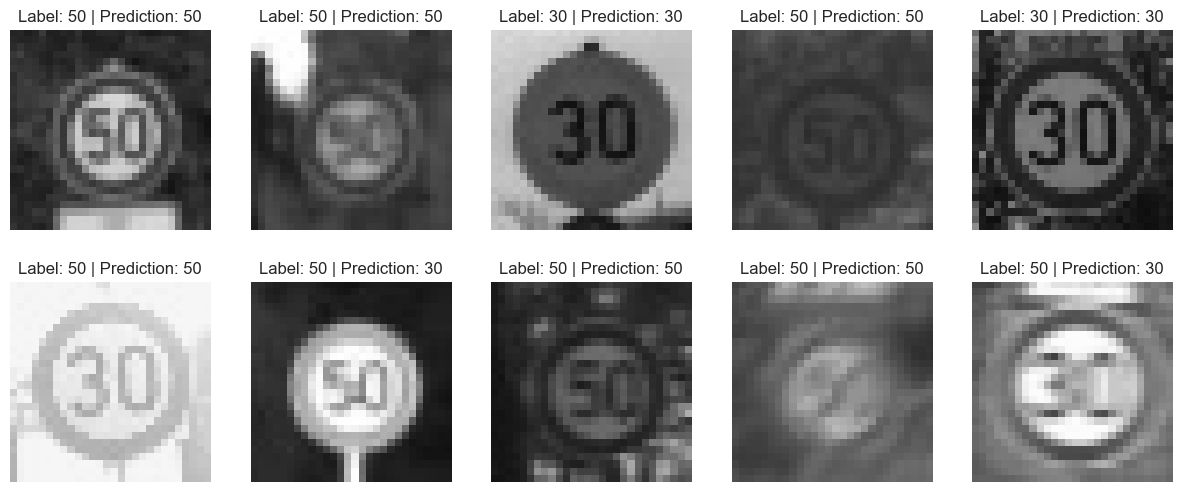

In [22]:
for cnt in range(10):
    idx = np.random.randint(0, len(X_test) + 1)
    plt.subplot(2,5,cnt+1), plt.imshow(images[idx], cmap='gray', vmin=0, vmax=255)
    predicted = '50' if predictions[idx] else '30'
    label = '50' if y_test[idx] else '30'
    plt.title('Label: ' + label + ' | Prediction: ' + predicted)
    plt.axis(False)

Text(0.5, 1.0, 'Confusion Matrix')

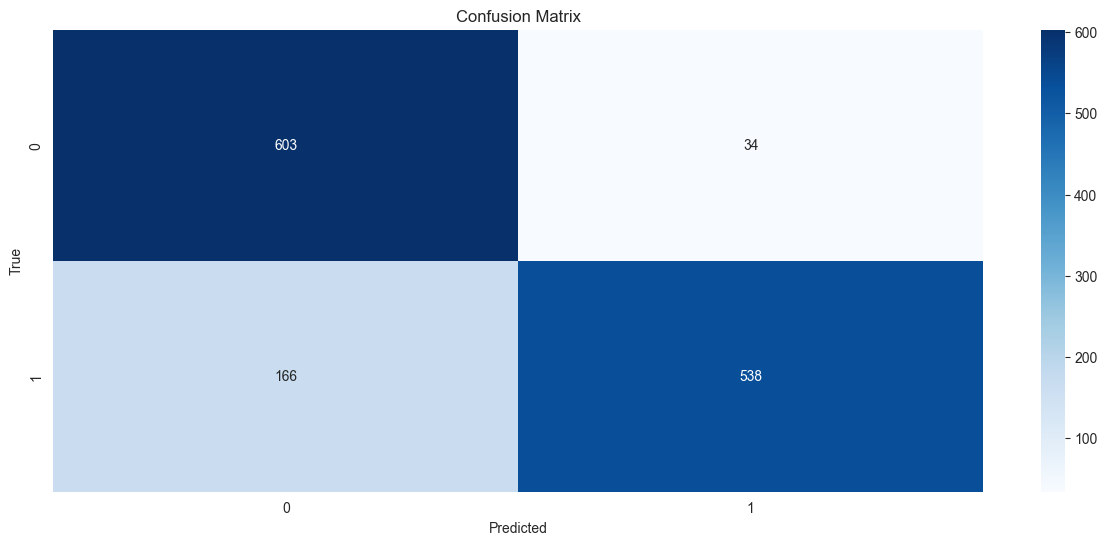

In [24]:
cm = confusion_matrix(y_test, predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')

In [25]:
report = classification_report(y_test,
                               predictions,
                               target_names=['Sign 30', 'Sign 50'])
print(report)

              precision    recall  f1-score   support

     Sign 30       0.78      0.95      0.86       637
     Sign 50       0.94      0.76      0.84       704

    accuracy                           0.85      1341
   macro avg       0.86      0.86      0.85      1341
weighted avg       0.87      0.85      0.85      1341



## Questions and Answers

In this homework, you are going to use the code from ```TrafficSignsClassification``` notebook and create your own traffic sign classifier.

### Step 1
Q: Use the data from ```data/subset_homework``` folder and visualize some examples. How many images are there for each class? <br/>
A: There are 2220 images for class_id_0 and 2250 images for class_id_1. The images are of traffic signs with speed limits of 30 and 50, respectively.

### Step 2
Q: Run the training with one single neuron (as we did in the lecture). What accuracy can you achieve?<br/>
A: About 97% of Accuracy for Single Neuron

### Step 3
Q: Make further modifications to improve the accuracy (e.g. add more neurons, more layers, etc.). What is the maximum accuracy you can achieve?<br/>
A: 98% of F1 Score with 3 hidden layers and 32, 16, 4 neurons respectively. The model was trained using the Huber loss function and the Adam optimizer, with early stopping and model checkpointing to prevent overfitting. The confusion matrix and classification report show that the model performs well in distinguishing between the two classes of traffic signs.
The images are grayscale and have varying brightness levels, which can be adjusted using the optimal factor calculated from the mean brightness of the images.

